In [1]:
import pandas as pd
import numpy as np


In [31]:
import pandas as pd
import numpy as np

np.random.seed(42)

data = []

for _ in range(1000):

    lines_changed = np.random.randint(10, 2000)

    files_changed = np.random.randint(1, 30)

    commits = np.random.randint(1, 10)

    past_bugs = np.random.randint(0, 20)

    risk_score = (
        lines_changed * 0.003 +
        files_changed * 0.2 +
        commits * 0.1 +
        past_bugs * 0.5
    )
    probability = 1 / (1 + np.exp(-(risk_score - 12)))

    bug_found = np.random.choice(
    [0, 1],
    p=[1 - probability, probability]
)

    data.append([
        lines_changed,
        files_changed,
        commits,
        past_bugs,
        bug_found
    ])

df = pd.DataFrame(
    data,
    columns=[
        "lines_changed",
        "files_changed",
        "commits",
        "past_bugs",
        "bug_found"
    ]
)

df.to_csv(
    "defect_prediction_1000.csv",
    index=False
)

print(df.head())
print(df.shape)

   lines_changed  files_changed  commits  past_bugs  bug_found
0           1136             20        8          6          0
1           1248             11        8          3          0
2            140             22        5          1          0
3           1447              6        2          0          0
4             31             29        9         16          1
(1000, 5)


In [32]:
import pandas as pd

df = pd.read_csv('../data/defect_prediction_1000.csv')
df

,lines_changed,files_changed,commits,past_bugs,bug_found
0,1136,20,8,6,0
1,1248,11,8,3,0
2,140,22,5,1,0
3,1447,6,2,0,0
4,31,29,9,16,1
...,...,...,...,...,...
995,1759,21,1,19,1
996,1176,26,4,14,1
997,798,24,9,4,0
998,884,16,7,3,0


## Separate Features and Target
### Concept

-- Think:

    Features (X) = Clues
    Target (y) = Answer

In [33]:
X=df.drop('bug_found', axis=1)
y=df['bug_found']

## Step 3: Train/Test Split

Why?

Imagine:

Teacher teaches student

Then immediately asks the same questions.

Student gets:

100%

But did he actually learn?

Maybe not.

So we split:

80% -> Training
20% -> Testing

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Step 4: Train Logistic Regression

In [35]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [36]:
predictions = model.predict(X_test)

print(predictions)

[0 1 0 1 0 0 0 1 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 1 1 0 0 0 1 0 0 0 0
 0 0 1 1 0 0 0 0 1 1 0 0 0 1 1 1 1 0 1 1 0 1 0 1 0 0 0 0 1 1 1 1 0 0 0 0 0
 1 0 1 0 0 1 0 0 1 0 0 1 0 0 0 0 1 0 0 1 0 0 1 1 0 1 0 1 0 1 1 0 1 0 0 1 0
 1 1 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 1 1 0 0 0 0 0 1 1 1 1 1 1 0 0 0
 1 1 1 0 1 1 0 1 1 1 0 1 1 0 0 1 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0
 0 0 0 0 0 0 1 1 0 0 1 1 1 1 0]


In [37]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 0.865


In [38]:
new_pr = [[2000, 25, 3, 20]]

print(model.predict(new_pr))

[1]


/Users/utpal.gohain/Documents/DS Project/Ml-project/.globalenv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [39]:
probability = model.predict_proba(new_pr)

print(probability)

[[2.15714406e-04 9.99784286e-01]]


/Users/utpal.gohain/Documents/DS Project/Ml-project/.globalenv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [40]:
new_pr = [[50,1,1,0]]

print(model.predict(new_pr))
print(model.predict_proba(new_pr))

[0]
[[9.99983626e-01 1.63737714e-05]]


/Users/utpal.gohain/Documents/DS Project/Ml-project/.globalenv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/utpal.gohain/Documents/DS Project/Ml-project/.globalenv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [41]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    predictions
)

print(cm)

[[107  12]
 [ 15  66]]


In [42]:
from sklearn.metrics import (
    precision_score,
    recall_score
)

print(
    "Precision:",
    precision_score(y_test, predictions)
)

print(
    "Recall:",
    recall_score(y_test, predictions)
)

Precision: 0.8461538461538461
Recall: 0.8148148148148148


In [43]:
print(model.coef_)

[[0.00285047 0.1849192  0.12172437 0.46106146]]


In [44]:
print(
    df["bug_found"].value_counts()
)

bug_found
0    571
1    429
Name: count, dtype: int64


In [45]:
feature_names = X.columns

for name, coef in zip(feature_names, model.coef_[0]):
    print(name, coef)

lines_changed 0.0028504687955544744
files_changed 0.18491920450529242
commits 0.12172436553662495
past_bugs 0.4610614561944857


## Interpretation
1. past_bugs (0.461) ⭐

Highest influence.

Meaning:

Modules with many historical bugs
are more likely to get new bugs.

As a QA Lead, does this make sense?

Absolutely.

Example:

Authentication Module
30 bugs last year

vs

Dashboard
2 bugs last year

Authentication is riskier.

2. files_changed (0.185)

Second strongest.

Meaning:

Touching many files
increases regression risk.

Again, very realistic.

3. commits (0.122)

Some influence.

More commits often means:

More changes
More rework
More complexity
4. lines_changed (0.003)

Very small.

This happened because of how we generated the synthetic data.

In a real project, lines changed is usually much more important.I

  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-macosx_10_15_universal2.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 56.7 MB/s  0:00:00
Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp314-cp314-macosx_10_15_universal2.whl (2.9 MB)
Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl (64 kB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to 

Matplotlib is building the font cache; this may take a moment.


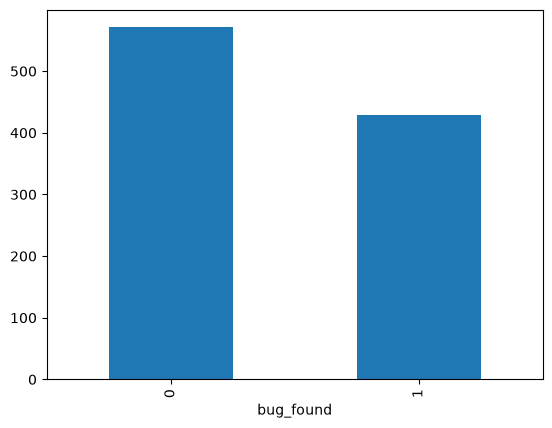

In [47]:
%pip install matplotlib

import matplotlib.pyplot as plt

df["bug_found"].value_counts().plot(kind="bar")

plt.show()


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


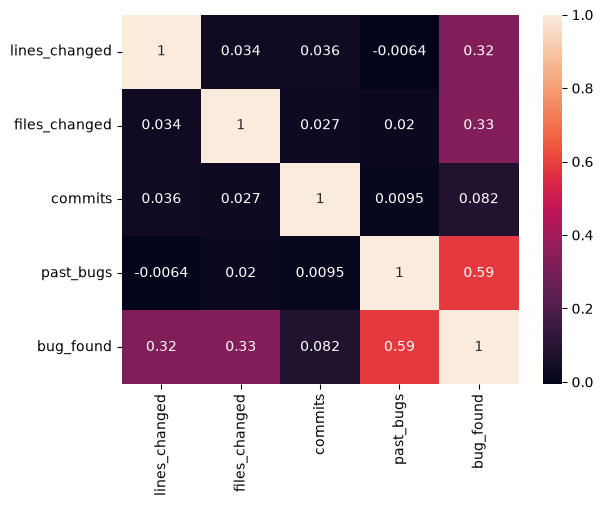

In [49]:
%pip install seaborn

import seaborn as sns

sns.heatmap(df.corr(), annot=True)

plt.show()

In [50]:
import joblib

joblib.dump(
    model,
    "defect_prediction_model.pkl"
)

print("Model Saved")

Model Saved
